# COMP 3610 Assignment 4: MLOps & Model Deployment

## Prerequisite
This assignment depends on models trained in Assignment 2. Before running this notebook, run all the cells in `assignment2.ipynb` in the COMP3610-Assignment2 GitHub repository. The models folder will be created automatically. To use them in this notebook, place the `models/` folder in the same directory as this notebook. The loading cell directly below this will import all four required files.

In [1]:
#Loading cell
import joblib
import json

rf_reg_tuned = joblib.load('models/rf_reg_tuned.pkl')
rf_reg = joblib.load('models/rf_reg.pkl')
scaler = joblib.load('models/scaler.pkl')

with open('models/feature_columns.json') as f:
    feature_columns = json.load(f)

print(f'Models loaded. Features: {len(feature_columns)}')

Models loaded. Features: 32


Download "yellow_tripdata_2024-01.parquet" and "taxi_zone_lookup.csv" files to "data/raw/" directory

In [2]:
#Download "yellow_tripdata_2024-01.parquet" and "taxi_zone_lookup.csv" files to "data/raw/" directory:
import os
import urllib.request

os.makedirs("data/raw/", exist_ok=True)

urllib.request.urlretrieve(
    "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet",
    "data/raw/yellow_tripdata_2024-01.parquet"
)

urllib.request.urlretrieve(
    "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv",
    "data/raw/taxi_zone_lookup.csv"
)

print("Files downloaded successfully.")

Files downloaded successfully.


Reconstruct test data by cleaning and performing feature engineering on the downloaded data in accordance with `COMP3610-Assignment2`

In [3]:
# Reconstruct test data (mirrors assignment2.ipynb pipeline exactly)
import polars as pl
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Load & clean raw data ---
df_polars = pl.read_parquet('data/raw/yellow_tripdata_2024-01.parquet')

df_credit_card = (
    df_polars
    .drop_nulls(subset=["tpep_pickup_datetime", "tpep_dropoff_datetime",
                         "PULocationID", "DOLocationID", "fare_amount"])
    .filter(
        (pl.col("trip_distance") > 0) &
        (pl.col("fare_amount") >= 0) &
        (pl.col("fare_amount") <= 500) &
        (pl.col("tpep_dropoff_datetime") >= pl.col("tpep_pickup_datetime")) &
        (pl.col("payment_type") == 1)
    )
)

# --- Feature engineering ---
df_features = df_credit_card.with_columns([
    pl.col("tpep_pickup_datetime").dt.hour().alias("pickup_hour"),
    pl.col("tpep_pickup_datetime").dt.weekday().alias("pickup_day_of_week"),
    ((pl.col("tpep_pickup_datetime").dt.weekday()) >= 5).cast(pl.Int8).alias("is_weekend"),
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
     .dt.total_seconds() / 60).alias("trip_duration_minutes"),
    (pl.col("trip_distance") /
     ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
      .dt.total_seconds() / 3600).clip(lower_bound=1e-6)).alias("trip_speed_mph"),
    pl.col("trip_distance").log1p().alias("log_trip_distance"),
    (pl.col("fare_amount") / pl.col("trip_distance").clip(lower_bound=1e-6)).alias("fare_per_mile"),
    (pl.col("fare_amount") /
     ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
      .dt.total_seconds() / 60).clip(lower_bound=1e-6)).alias("fare_per_minute"),
])

# --- Borough one-hot encoding ---
zone_lookup = pl.read_csv('data/raw/taxi_zone_lookup.csv')

columns_to_drop = [
    col for col in df_features.columns
    if col in ('pickup_borough', 'dropoff_borough')
    or col.startswith('pickup_borough_')
    or col.startswith('dropoff_borough_')
]
if columns_to_drop:
    df_features = df_features.drop(columns_to_drop)

pu_borough = zone_lookup.select([pl.col('LocationID').alias('PULocationID'), pl.col('Borough').alias('pickup_borough')])
do_borough = zone_lookup.select([pl.col('LocationID').alias('DOLocationID'), pl.col('Borough').alias('dropoff_borough')])

df_features = (
    df_features
    .join(pu_borough, on='PULocationID', how='left')
    .join(do_borough, on='DOLocationID', how='left')
    .with_columns([
        pl.col('pickup_borough').fill_null('Unknown'),
        pl.col('dropoff_borough').fill_null('Unknown'),
    ])
)

pu_dummies = df_features.select('pickup_borough').to_dummies()
do_dummies = df_features.select('dropoff_borough').to_dummies()
pu_dummies = pu_dummies.drop(sorted(pu_dummies.columns)[0])
do_dummies = do_dummies.drop(sorted(do_dummies.columns)[0])

df_features = pl.concat([df_features, pu_dummies, do_dummies], how='horizontal')
df_features = df_features.drop(['pickup_borough', 'dropoff_borough'])

# --- Targets ---
df_features = df_features.with_columns([
    (pl.col('tip_amount') > 0.20 * pl.col('fare_amount')).alias('high_tip')
])
y_reg   = df_features['tip_amount'].to_numpy()
y_class = df_features['high_tip'].to_numpy()

# --- Features (use the saved feature_columns to guarantee same order/set) ---
float_feat_cols = [c for c in feature_columns if df_features[c].dtype in (pl.Float64, pl.Float32)]
fill_exprs = [pl.col(c).fill_null(pl.col(c).median()).alias(c) for c in float_feat_cols]
df_filled = df_features.with_columns(fill_exprs) if fill_exprs else df_features

X = df_filled.select(feature_columns).to_numpy().astype(np.float64)
col_medians = np.nanmedian(np.where(np.isinf(X), np.nan, X), axis=0)
X = np.where(np.isnan(X) | np.isinf(X), col_medians, X)

# --- Split (identical seeds & ratios to assignment2) ---
X_train, X_temp, y_reg_train, y_reg_temp, y_class_train, y_class_temp = train_test_split(
    X, y_reg, y_class, test_size=0.30, random_state=42, stratify=y_class
)
X_val, X_test, y_reg_val, y_reg_test, y_class_val, y_class_test = train_test_split(
    X_temp, y_reg_temp, y_class_temp, test_size=0.50, random_state=42, stratify=y_class_temp
)

# --- Scale using the LOADED scaler (do NOT refit) ---
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'Test set ready: {X_test_scaled.shape[0]:,} rows, {X_test_scaled.shape[1]} features')

Test set ready: 344,762 rows, 32 features


## Part 1: Experiment Tracking with MLflow

### Task 1.1: MLflow Setup & Experiment Logging
Before running the cells below, start the MLflow tracking server in a separate terminal:
```
mlflow ui --port 5000
```
Then open http://localhost:5000 to view the MLflow dashboard.

Set up a local MLflow tracking server, configure notebook to log to it and create an MLflow experiment named "taxi-tip-prediction"

In [4]:
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Point to local tracking server
mlflow.set_tracking_uri('http://localhost:5000')

# Create experiment
mlflow.set_experiment('taxi-tip-prediction')

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('Experiment set: taxi-tip-prediction')

2026/04/16 15:53:07 INFO mlflow.tracking.fluent: Experiment with name 'taxi-tip-prediction' does not exist. Creating a new experiment.


MLflow tracking URI: http://localhost:5000
Experiment set: taxi-tip-prediction


Helper function for metrics (MAE, RMSE, and R²) to avoid repeated metric logging

In [5]:
# Helper function to avoid repeating metric logging
def log_regression_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mlflow.log_metric('mae',  mae)
    mlflow.log_metric('rmse', rmse)
    mlflow.log_metric('r2',   r2)
    return mae, rmse, r2

Load and evaluate baseline random forest regressor from `COMP3610-Assignment2` (logging the hyperparameters, metrics, trained model, and tags)

In [6]:
# Run 1: Baseline Random Forest Regressor
with mlflow.start_run(run_name='baseline-random-forest'):

    # Log hyperparameters
    params = {
        'n_estimators': rf_reg.n_estimators,
        'max_depth': rf_reg.max_depth,
        'random_state': rf_reg.random_state
    }
    mlflow.log_params(params)

    # Evaluate on test set
    preds = rf_reg.predict(X_test_scaled)
    baseline_mae, baseline_rmse, baseline_r2 = log_regression_metrics(y_reg_test, preds)

    # Tags
    mlflow.set_tag('model_type',      'RandomForestRegressor')
    mlflow.set_tag('dataset_version', 'yellow_tripdata_2024-01')

    # Log model artifact
    mlflow.sklearn.log_model(rf_reg, 'model')

    print(f'Baseline RF  |  MAE: {baseline_mae:.4f}  RMSE: {baseline_rmse:.4f}  R2: {baseline_r2:.4f}')

2026/04/16 15:53:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 15:53:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Baseline RF  |  MAE: 1.2037  RMSE: 2.3381  R2: 0.6260
🏃 View run baseline-random-forest at: http://localhost:5000/#/experiments/1/runs/2247d7b54d4a48b9a7bf55dd1d3f405e
🧪 View experiment at: http://localhost:5000/#/experiments/1


Load and evaluate tuned random forest regressor from `COMP3610-Assignment2` (logging the hyperparameters, metrics, trained model, and tags)

In [7]:
# Run 2: Tuned Random Forest Regressor
with mlflow.start_run(run_name='tuned-random-forest'):

    # Log hyperparameters
    params = {
        'n_estimators': rf_reg_tuned.n_estimators,
        'max_depth': rf_reg_tuned.max_depth,
        'min_samples_split': rf_reg_tuned.min_samples_split,
        'max_features': rf_reg_tuned.max_features,
        'max_samples': rf_reg_tuned.max_samples,
        'random_state': rf_reg_tuned.random_state
    }
    mlflow.log_params(params)

    # Evaluate on test set
    preds = rf_reg_tuned.predict(X_test_scaled)
    tuned_mae, tuned_rmse, tuned_r2 = log_regression_metrics(y_reg_test, preds)

    # Tags
    mlflow.set_tag('model_type', 'TunedRandomForestRegressor')
    mlflow.set_tag('dataset_version', 'yellow_tripdata_2024-01')

    # Log model artifact and register in one step
    mlflow.sklearn.log_model(
        rf_reg_tuned,
        'model'
    )

    print(f'Tuned RF     |  MAE: {tuned_mae:.4f}  RMSE: {tuned_rmse:.4f}  R2: {tuned_r2:.4f}')

    best_run_id = mlflow.active_run().info.run_id
    print(f'Run ID: {best_run_id}')

2026/04/16 15:53:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 15:53:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuned RF     |  MAE: 1.1979  RMSE: 2.2853  R2: 0.6427
Run ID: e18fbf7def174d918c515da5b87ea31d
🏃 View run tuned-random-forest at: http://localhost:5000/#/experiments/1/runs/e18fbf7def174d918c515da5b87ea31d
🧪 View experiment at: http://localhost:5000/#/experiments/1


#### MLflow UI - Logged Runs

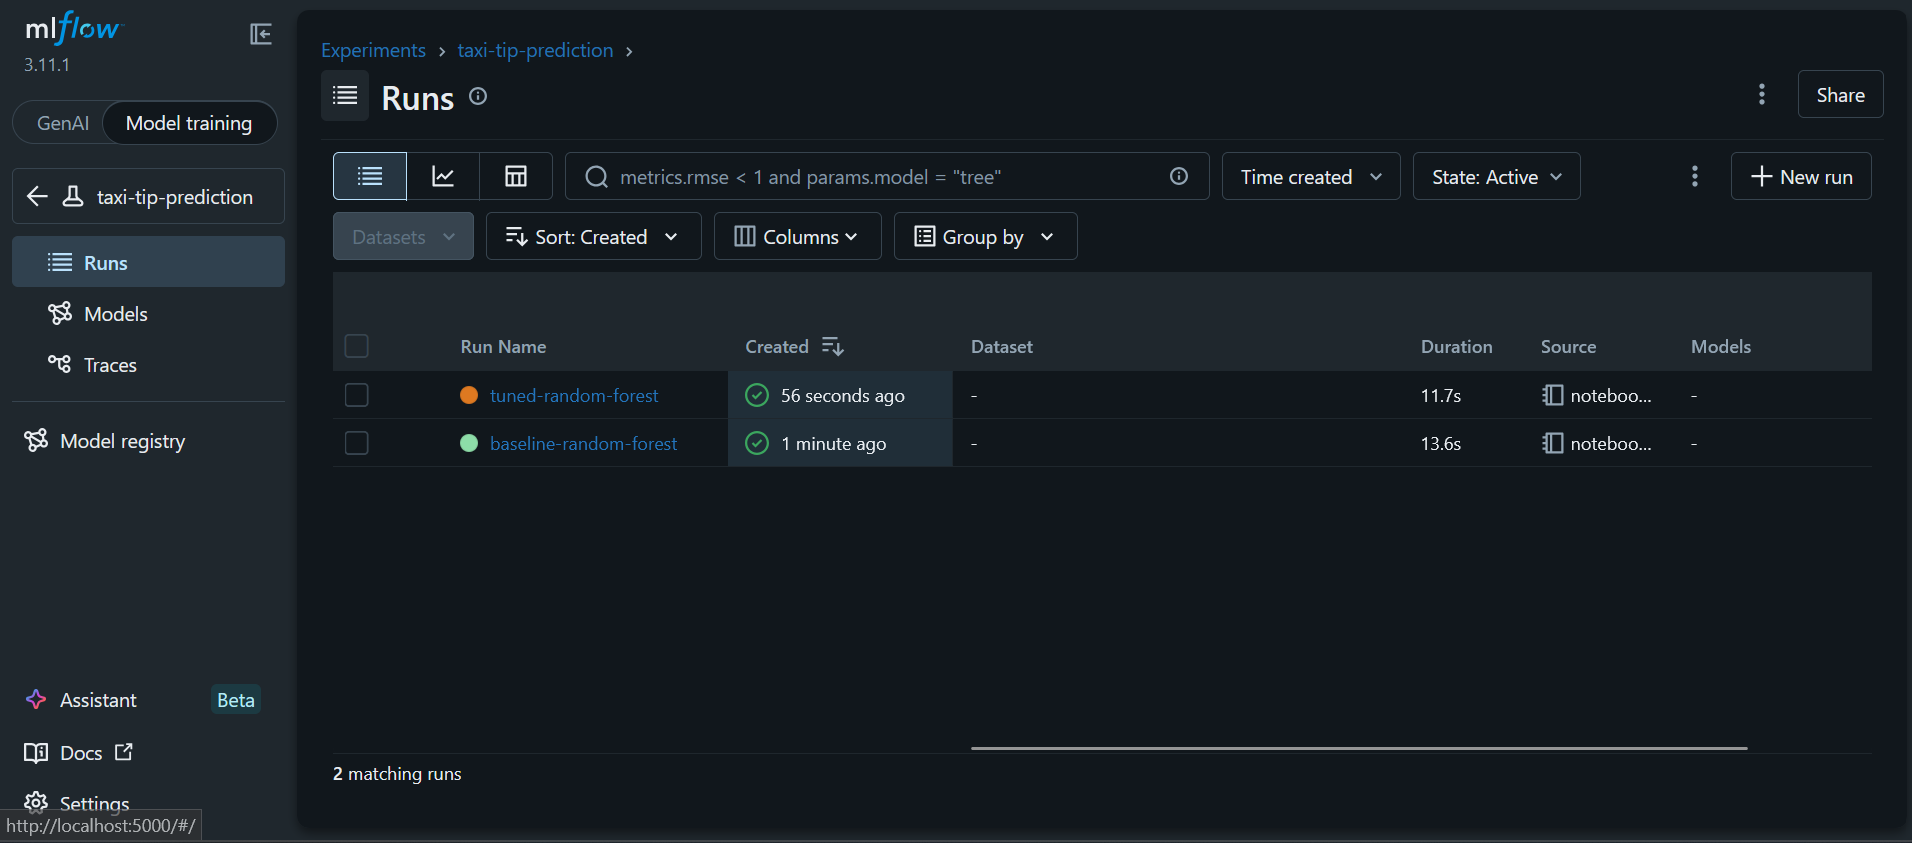

### Task 1.2: Model Comparison & Registry

#### MLflow UI - Comparison View

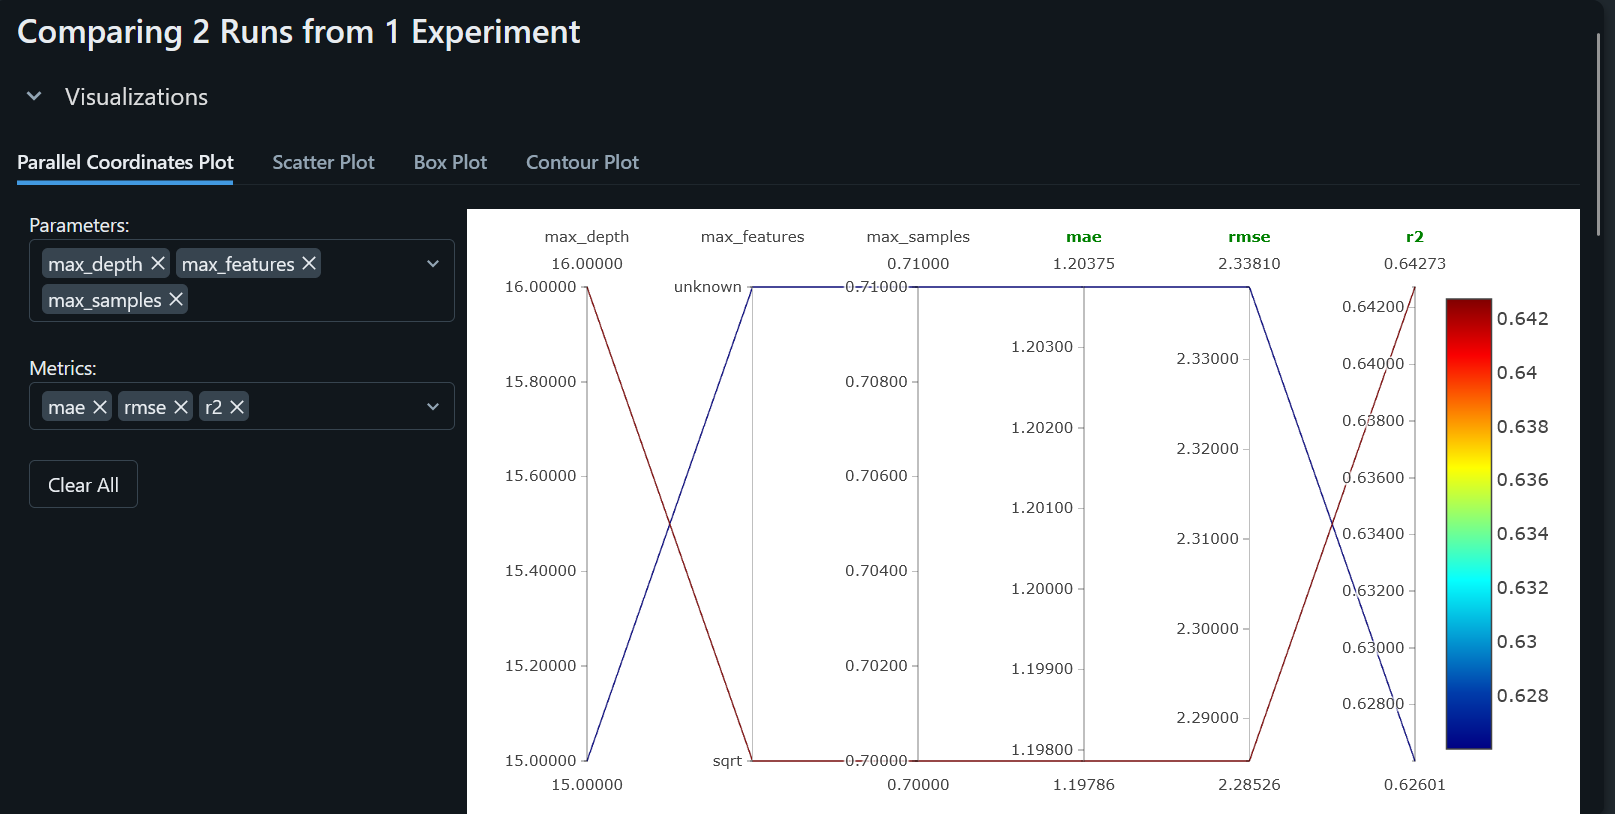

#### Model Comparison Analysis
The tuned Random Forest Regressor outperformed the baseline across all three metrics, achieving a lower MAE (1.198 < 1.204), lower RMSE (2.285 < 2.338), and higher R² (0.643 > 0.626) on the test set. This is expected as RandomizedSearchCV optimised the key hyperparameters (`n_estimators`, `max_depth`, `min_samples_split`) over 20 iterations with 5-fold cross-validation, selecting the combination that minimised MAE. The baseline model used fixed default-like values for these parameters and was therefore less well-suited to the structure of this dataset.

Register tuned random forest regressor (best performing model) with the name 'taxi-tip-regressor' and a ersion description documenting its performance

In [8]:
# Register best model (tuned random forest regressor) in the MLflow Model Registry 
from mlflow.tracking import MlflowClient

result = mlflow.register_model(
    model_uri=f'runs:/{best_run_id}/model',
    name='taxi-tip-regressor'
)
print('Registered taxi-tip-regressor model version:', result.version)

# Add a descriptive version description documenting performance
client = MlflowClient('http://localhost:5000')
client.update_model_version(
    name='taxi-tip-regressor',
    version=result.version,
    description=(
        f'Tuned Random Forest Regressor trained on NYC Yellow Taxi '
        f'trip data (yellow_tripdata_2024-01). '
        f'Test-set metrics: MAE={tuned_mae:.4f}, RMSE={tuned_rmse:.4f}, '
        f'R²={tuned_r2:.4f}. '
        f'Hyperparameters tuned via grid search in Assignment 2.'
    )
)
print(f'Description added to version {result.version}.')

# Transition to Production stage
client.transition_model_version_stage(
    name='taxi-tip-regressor',
    version=result.version,
    stage='Production'
)
print(f'Version {result.version} transitioned to Production.')

Successfully registered model 'taxi-tip-regressor'.
2026/04/16 15:53:31 WARNING mlflow.tracking._model_registry.fluent: Run with id e18fbf7def174d918c515da5b87ea31d has no artifacts at artifact path 'model', registering model based on models:/m-21928ccd4c53450b95820add667b4958 instead
2026/04/16 15:53:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 1


Registered taxi-tip-regressor model version: 1
Description added to version 1.
Version 1 transitioned to Production.


Created version '1' of model 'taxi-tip-regressor'.
C:\Users\User\AppData\Local\Temp\ipykernel_14168\3980561753.py:26: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


Load the taxi-tip-regressor model from the registry and make a prediction using the actual tip value as a comparison

In [9]:
# Load the Production model from the registry and make a sample prediction
production_model = mlflow.sklearn.load_model("models:/taxi-tip-regressor/Production")

# Use the first row of the test set as a sample
sample = X_test_scaled[[0]]
predicted_tip = production_model.predict(sample)
actual_tip = y_reg_test[0]

print(f"Sample prediction: ${predicted_tip[0]:.2f}")
print(f"Actual tip_amount: ${actual_tip:.2f}")

Sample prediction: $1.91
Actual tip_amount: $2.00


## Part 2: Model Serving with FastAPI

### Task 2.1: API Design & Implementation
Completed in app.py

### Task 2.2: Enhanced API Features
Completed in app.py

### Task 2.3: API Testing 
Tests written in test_app.py. All tests passing in output shown below:
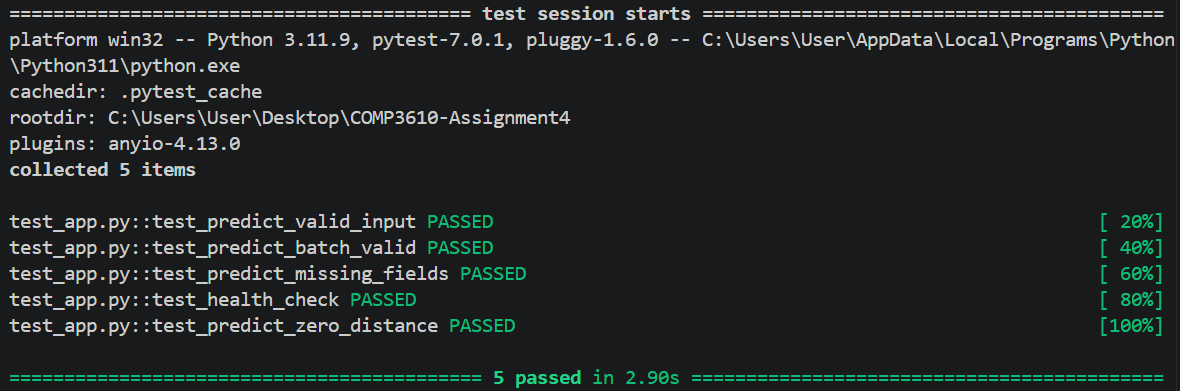
Swagger UI screenshot demonstrating API documentation:
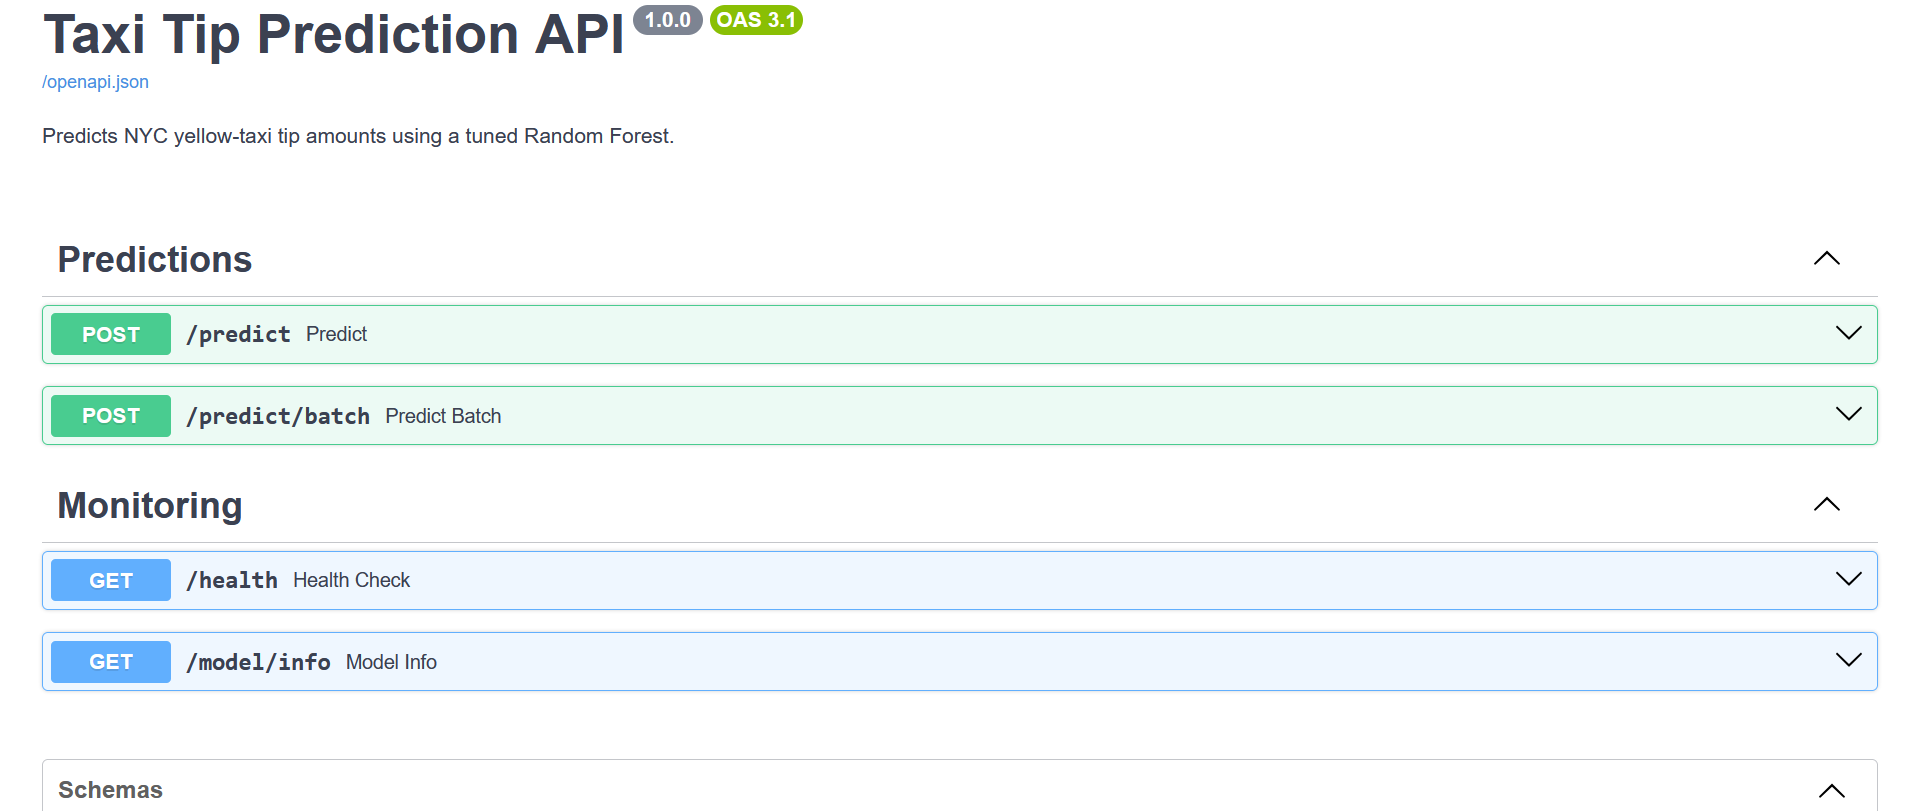

## Part 3: Containerization with Docker

### Task 3.1: Dockerfile & Image Building
Image size is 357MB
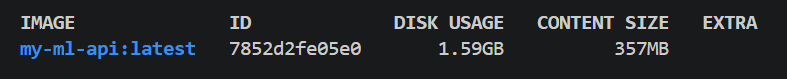

Verification that the API is accessible by making a test prediction from outside the container:
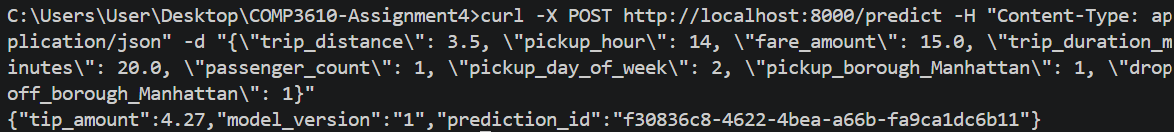

### Task 3.2: Docker Compose & Deployment Demo

#### Full Workflow

##### Start
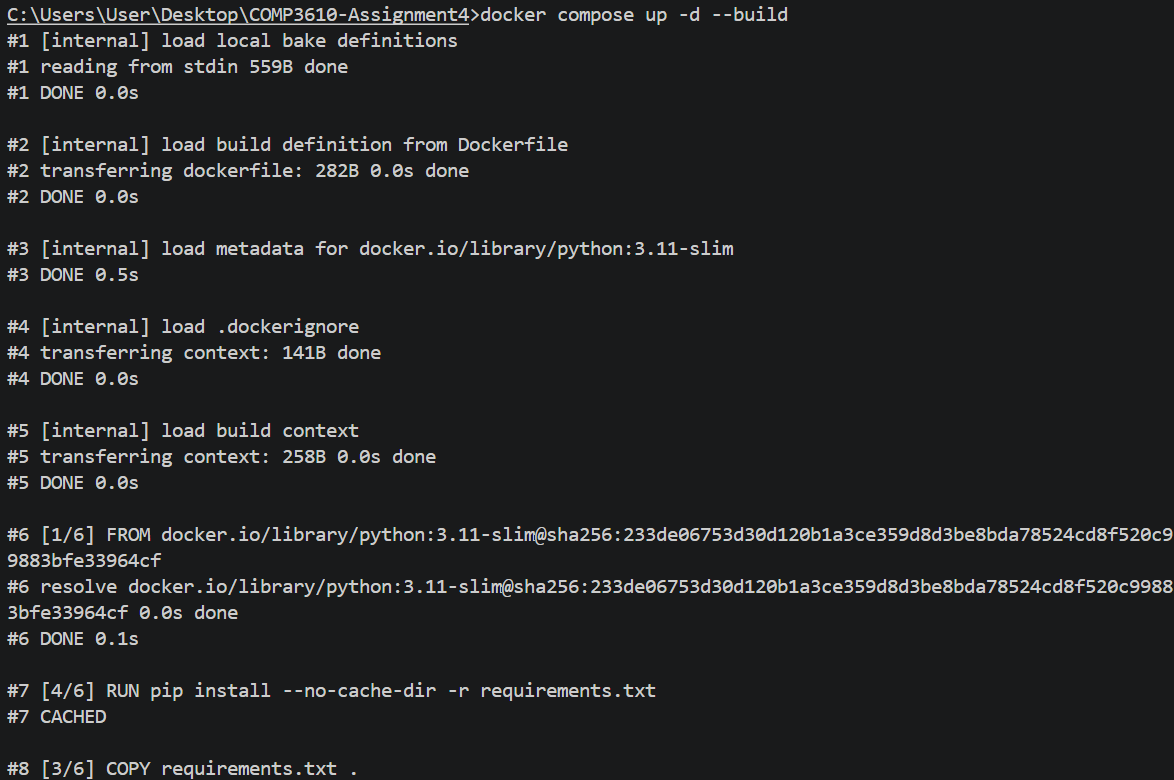
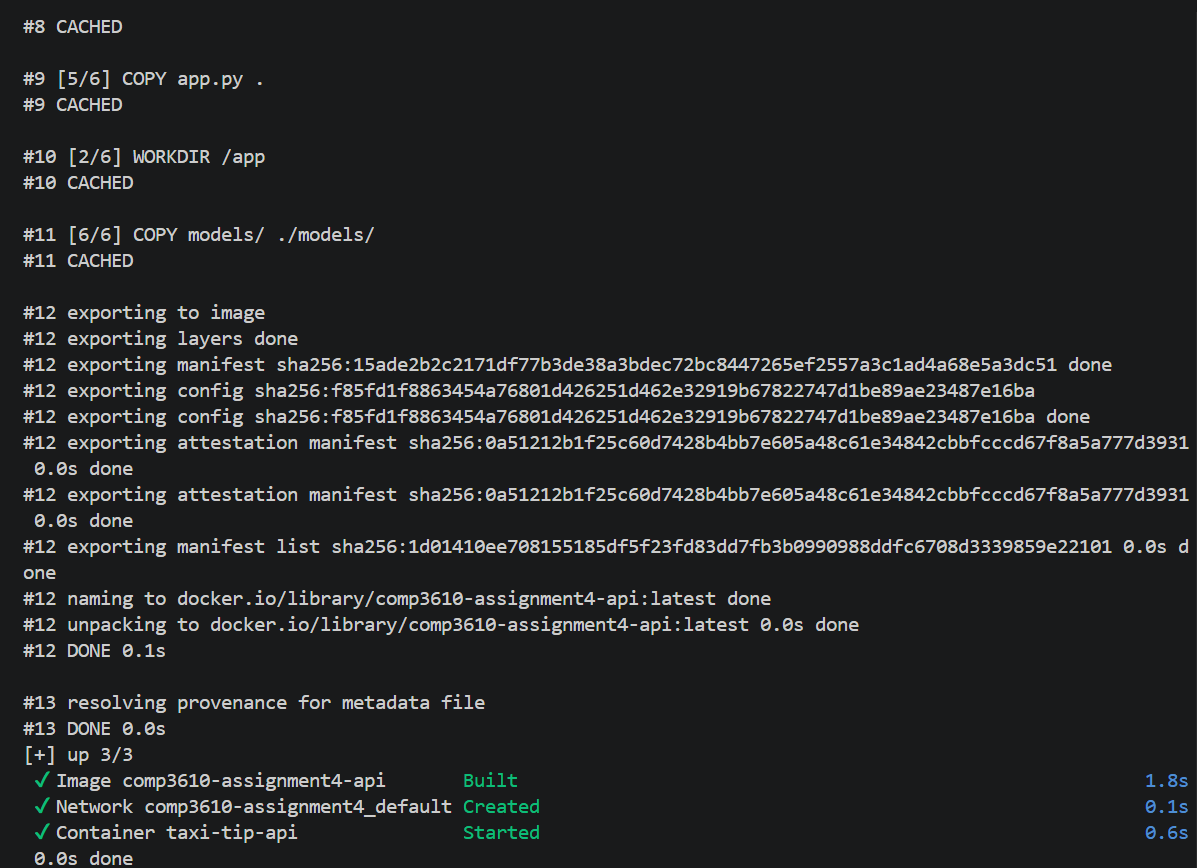

##### Predictions
1) 
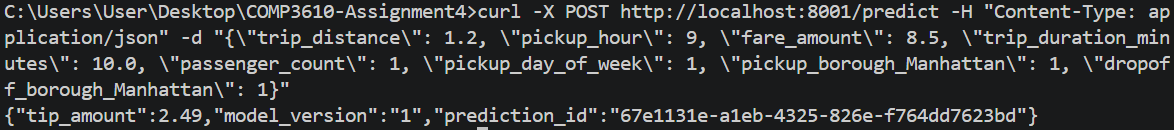

2) 
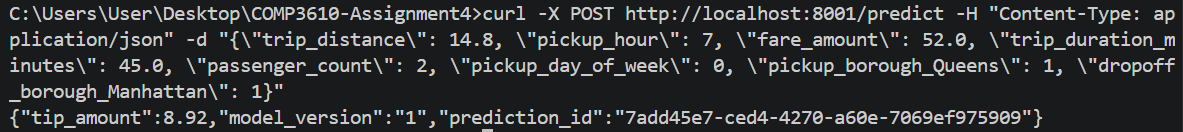

3) 
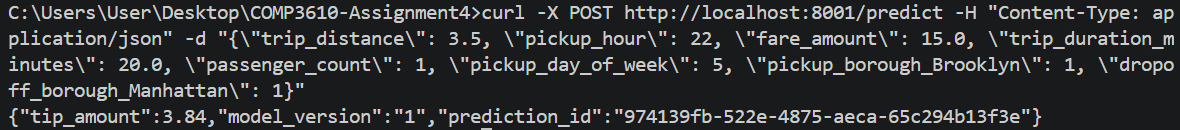

##### Stop
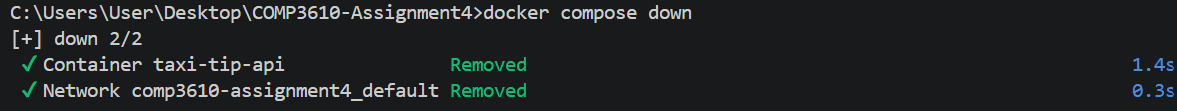

##### Container Size (357 MB)
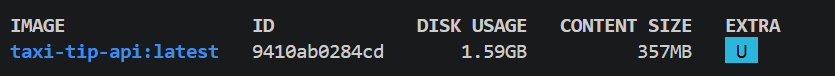

##### Configuration Required
Prerequisites:
1) Docker Desktop installed and running
2) `models/` folder present in the project root containing:

    - `rf_reg_tuned.pkl`
    - `scaler.pkl`
    - `feature_columns.json`

    (`assignment2.ipynb` in the `COMP3610-Assignment2` repository must be run and models in the resulting `models/` folder should be added to this project)

3) Port 8001 free on your machine

To run:

`docker compose up -d --build`

To stop:

`docker compose down`

## AI Disclaimer

Claude (Anthropic) was used for troubleshooting, as well as, for assistance in understanding how to apply the information from the guides to the required tasks.